In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np
from pathlib import Path
import sys, os
from sklearn.ensemble import RandomForestRegressor


## Carga del dataset 

In [3]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

fechas = pd.date_range(start="2025-01-01", end="2025-12-31")
lista_dfs = []
#Cargamos el año entero para luego filtrarlo (quedándonos solo con días con condiciones extremas)
for fecha in fechas:
    date = fecha.strftime('%Y-%m-%d')
    ruta_archivo = f"grupo5/cleaned/clima_clean/date={date}/clima_{date}.parquet"
    
    try:
        df_dia = download_df_parquet(access_key, secret_key, ruta_archivo)
        if df_dia is not None and not df_dia.empty:
            lista_dfs.append(df_dia)
    
    except Exception as e:
        pass

df = pd.concat(lista_dfs, ignore_index=True)

df

,Date,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,hour,is_rush_hour
0,2025-01-01 00:00:00+00:00,9.85,0.0,0.0,36.069233,0.0,100.0,5.994055,0.0,0,0,0,0
1,2025-01-01 01:00:00+00:00,9.80,0.0,0.0,39.575855,0.0,100.0,5.729144,0.0,0,0,1,0
2,2025-01-01 02:00:00+00:00,10.15,0.3,0.3,43.606834,0.0,100.0,5.989700,0.3,0,0,2,0
3,2025-01-01 03:00:00+00:00,10.40,1.6,1.6,42.518116,0.0,100.0,6.379945,1.9,0,0,3,0
4,2025-01-01 04:00:00+00:00,10.60,4.6,4.6,37.991940,0.0,100.0,6.881816,6.5,0,0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8740,2025-12-31 19:00:00+00:00,0.50,0.0,0.0,36.838482,0.0,100.0,-6.463588,0.0,0,0,19,1
8741,2025-12-31 20:00:00+00:00,0.80,0.0,0.0,35.816383,0.0,95.0,-5.976903,0.0,0,0,20,0
8742,2025-12-31 21:00:00+00:00,1.05,0.0,0.0,35.664082,0.0,64.0,-5.632567,0.0,0,0,21,0
8743,2025-12-31 22:00:00+00:00,1.15,0.0,0.0,34.674183,0.0,58.0,-5.413290,0.0,0,0,22,0


## Filtramos por clima extremo

In [4]:
condicion_extrema = (
    (df['Precipitation'] > 10.0) |      # Lluvia torrencial (> 10 mm por hora)
    (df['precip_3h_accum'] > 25.0) |    # Mucha lluvia acumulada
    (df['Temperature'] < -5.0) |        # Frío extremo (Heladas severas)
    (df['Temperature'] > 35.0) |        # Ola de calor extrema
    (df['Wind Speed'] > 40.0) |         # Viento muy fuerte/Gale
    (df['Snow'] > 0)                    # Cualquier presencia de nieve (suele ser caótica)
)

#Creamos una nueva columna para etiquetar estos momentos
df['clima_extremo'] = condicion_extrema.apply(lambda x: 'Extremo' if x else 'Normal')

#Vemos cuántos registros caen en esta categoría
print("--- Distribución de Condiciones Climáticas ---")
print(df['clima_extremo'].value_counts(normalize=True) * 100) # En porcentaje
print("\nRegistros totales extremos:", len(df[df['clima_extremo'] == 'Extremo']))

#Dataframe con solo los momentos extremos
df_extremos = df[df['clima_extremo'] == 'Extremo']

--- Distribución de Condiciones Climáticas ---
clima_extremo
Normal     84.894225
Extremo    15.105775
Name: proportion, dtype: float64

Registros totales extremos: 1321


## Análisis de componentes generales

### Información general del dataset (estructura y tipo de datos)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8745 entries, 0 to 8744
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   Date             8745 non-null   datetime64[ms, UTC]
 1   Temperature      8745 non-null   float32            
 2   Rain             8745 non-null   float32            
 3   Precipitation    8745 non-null   float32            
 4   Wind Speed       8745 non-null   float32            
 5   Snow             8745 non-null   float32            
 6   Cloud Cover      8745 non-null   float32            
 7   apparent_temp    8745 non-null   float64            
 8   precip_3h_accum  8745 non-null   float64            
 9   is_freezing      8745 non-null   int64              
 10  is_high_wind     8745 non-null   int64              
 11  hour             8745 non-null   int32              
 12  is_rush_hour     8745 non-null   int64              
 13  clima_extremo    8

### Comprobación de calidad (nulos y duplicados)

In [6]:
print("\n--- Conteo de Valores Nulos por Columna ---")
display(df.isnull().sum())

print("\n--- Filas Duplicadas ---")
num_duplicados = df.duplicated().sum()
print(f"Número de filas completamente duplicadas: {num_duplicados}")


--- Conteo de Valores Nulos por Columna ---


Date               0
Temperature        0
Rain               0
Precipitation      0
Wind Speed         0
Snow               0
Cloud Cover        0
apparent_temp      0
precip_3h_accum    0
is_freezing        0
is_high_wind       0
hour               0
is_rush_hour       0
clima_extremo      0
dtype: int64


--- Filas Duplicadas ---
Número de filas completamente duplicadas: 0


### Comprobación del rango temporal del dataset (para poder cruzarlo con otros)

In [7]:
fecha_inicio = df['Date'].min()
fecha_fin = df['Date'].max()

print(f"\nRango temporal del dataset:")
print(f"Desde: {fecha_inicio}")
print(f"Hasta: {fecha_fin}")
print(f"Total de registros (horas observadas): {len(df)}")


Rango temporal del dataset:
Desde: 2025-01-01 00:00:00+00:00
Hasta: 2025-12-31 23:00:00+00:00
Total de registros (horas observadas): 8745


## Análisis univariante (Características de las variables)

### Estadísticas de las variables continuas

In [8]:
display(df.describe().round(2))

,Temperature,Rain,Precipitation,Wind Speed,Snow,Cloud Cover,apparent_temp,precip_3h_accum,is_freezing,is_high_wind,hour,is_rush_hour
count,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00,8745.00
mean,12.30,0.12,0.12,26.21,0.00,55.90,9.85,0.36,0.07,0.04,11.50,0.29
std,8.21,0.67,0.68,12.15,0.06,43.49,10.81,1.56,0.26,0.19,6.91,0.45
min,-7.70,0.00,0.00,0.54,0.00,0.00,-16.53,0.00,0.00,0.00,0.00,0.00
25%,5.60,0.00,0.00,17.34,0.00,5.00,1.14,0.00,0.00,0.00,6.00,0.00
50%,12.75,0.00,0.00,24.82,0.00,69.00,10.44,0.00,0.00,0.00,12.00,0.00
75%,20.05,0.00,0.00,34.11,0.00,100.00,20.06,0.00,0.00,0.00,17.00,1.00
max,28.05,20.10,20.10,79.53,1.75,100.00,30.11,34.40,1.00,1.00,23.00,1.00


### Gráficos de distribución de las variables climáticas continuas

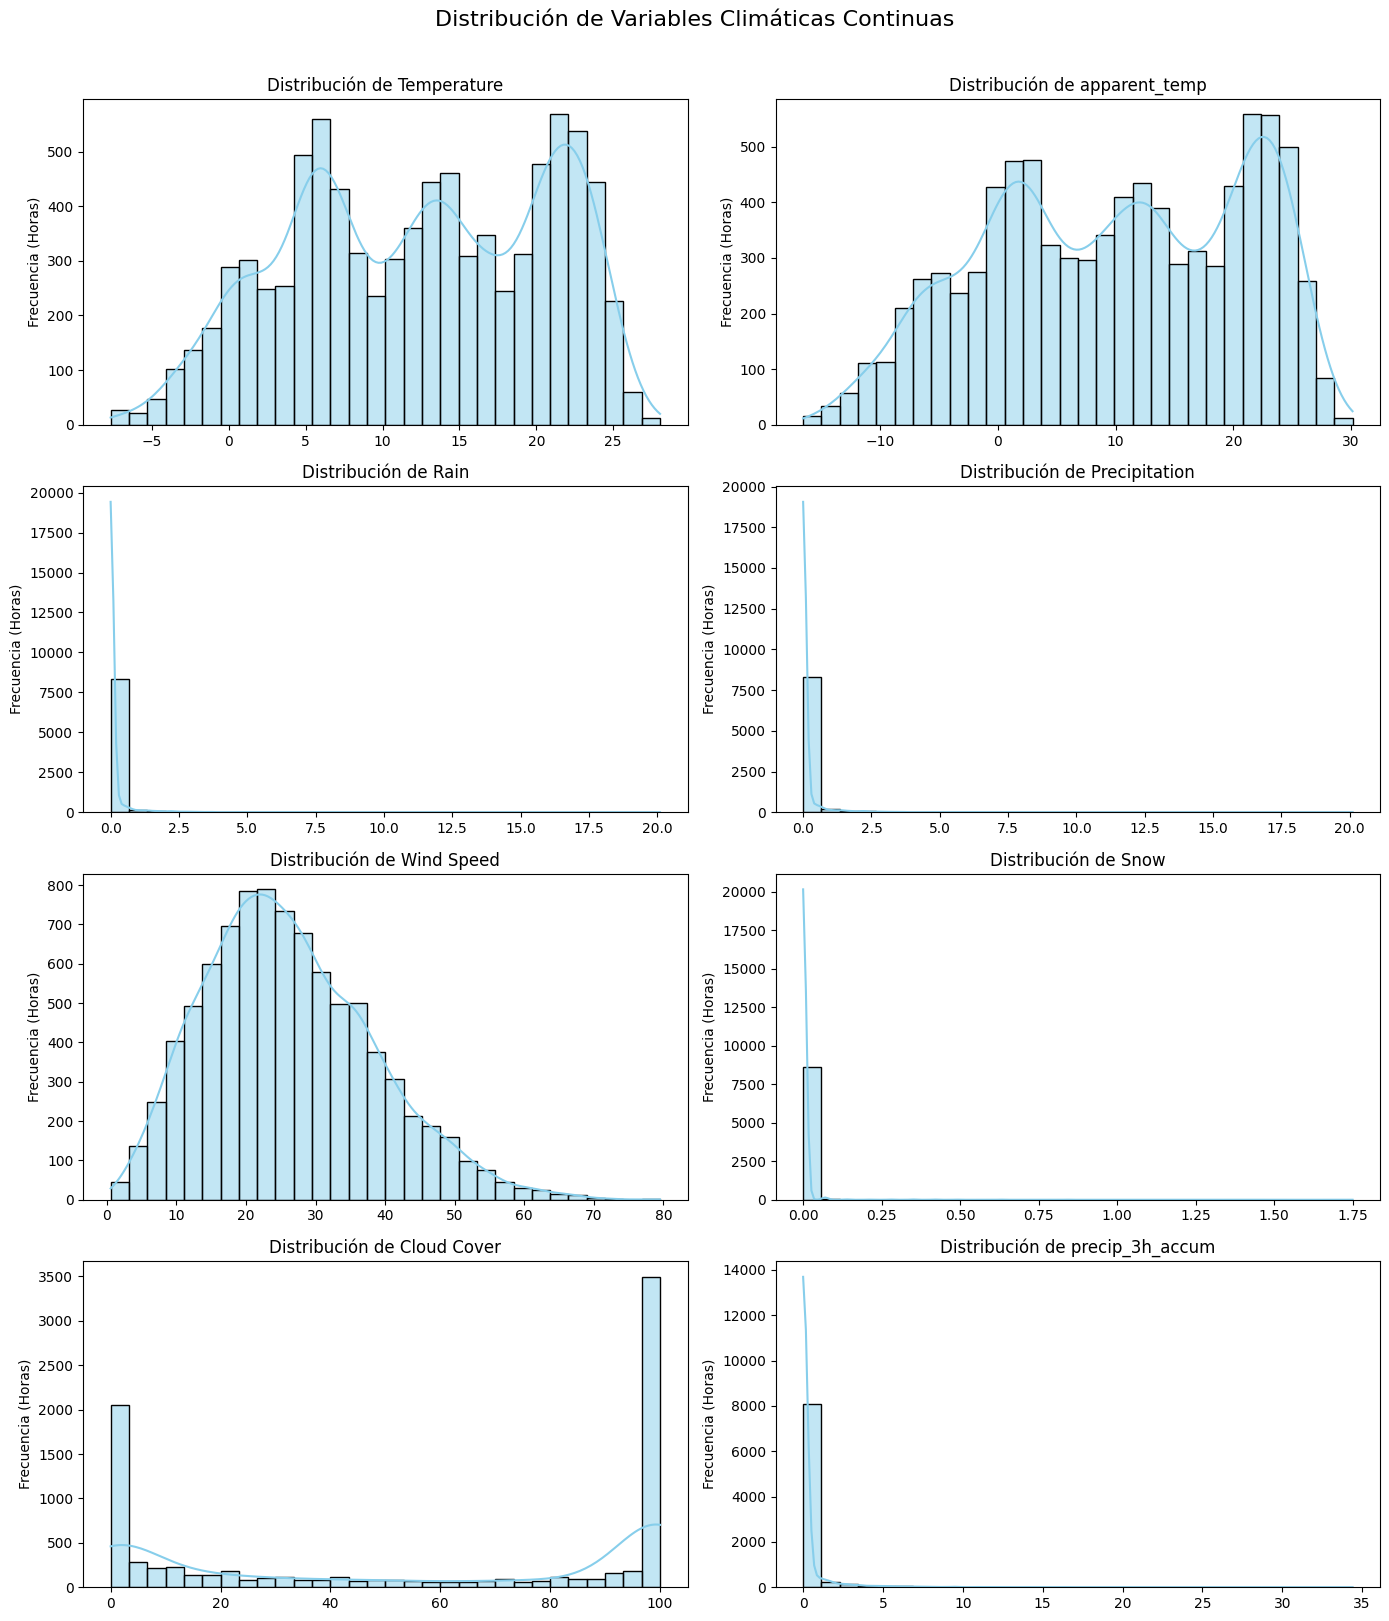

In [9]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

ncols = 2
nrows = 4

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 16))
fig.suptitle('Distribución de Variables Climáticas Continuas', fontsize=16, y=1.01)

axes = axes.flatten()

# Bucle para dibujar cada variable
for i, var in enumerate(vars_continuas):
    sns.histplot(df[var], bins=30, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribución de {var}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia (Horas)')

plt.tight_layout()
plt.show()

### Boxplots para detectar outliers

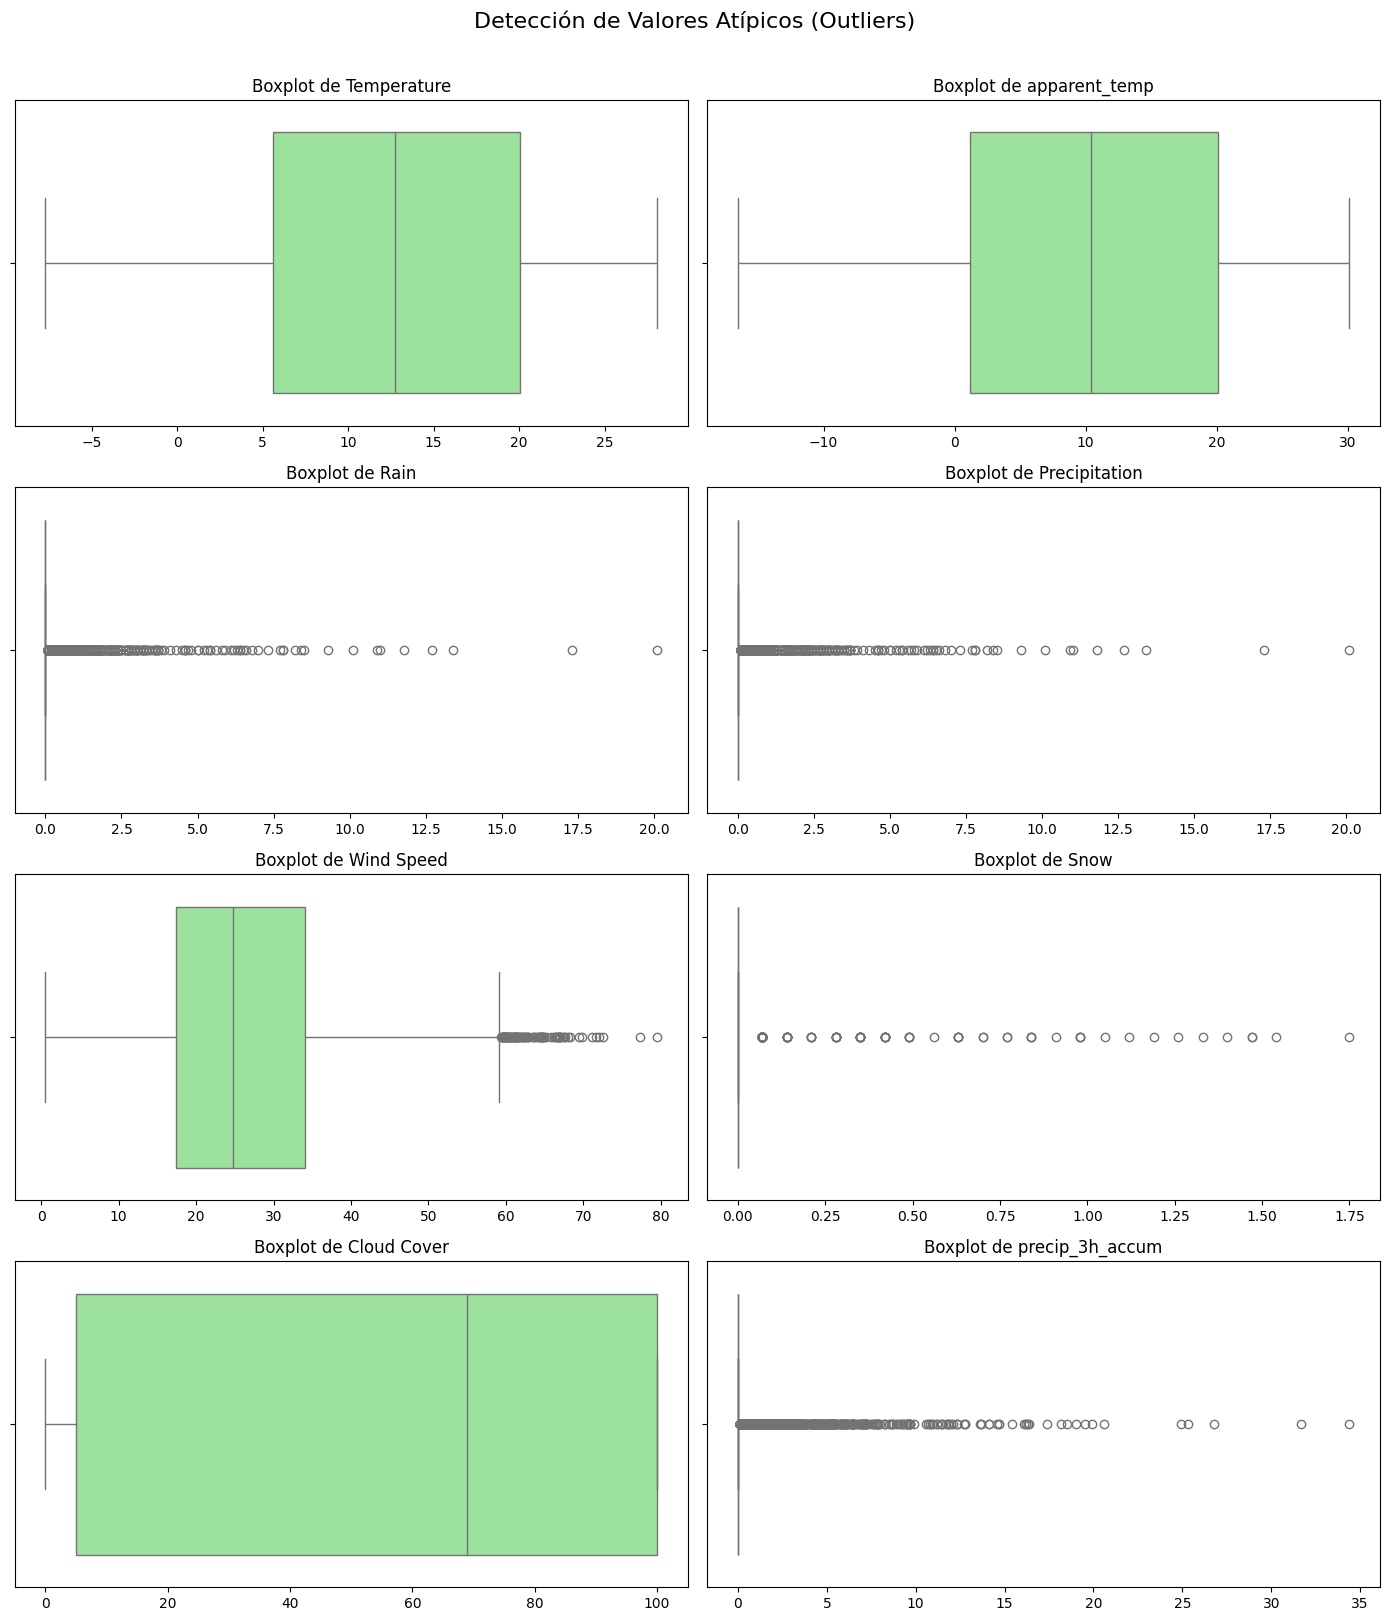

In [10]:
vars_continuas = [
    'Temperature', 'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed', 'Snow', 'Cloud Cover', 'precip_3h_accum'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Detección de Valores Atípicos (Outliers)', fontsize=16, y=1.01)

axes = axes.flatten()

for i, var in enumerate(vars_continuas):
    sns.boxplot(x=df[var], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot de {var}', fontsize=12)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

### Frecuencia de las variables binarias 

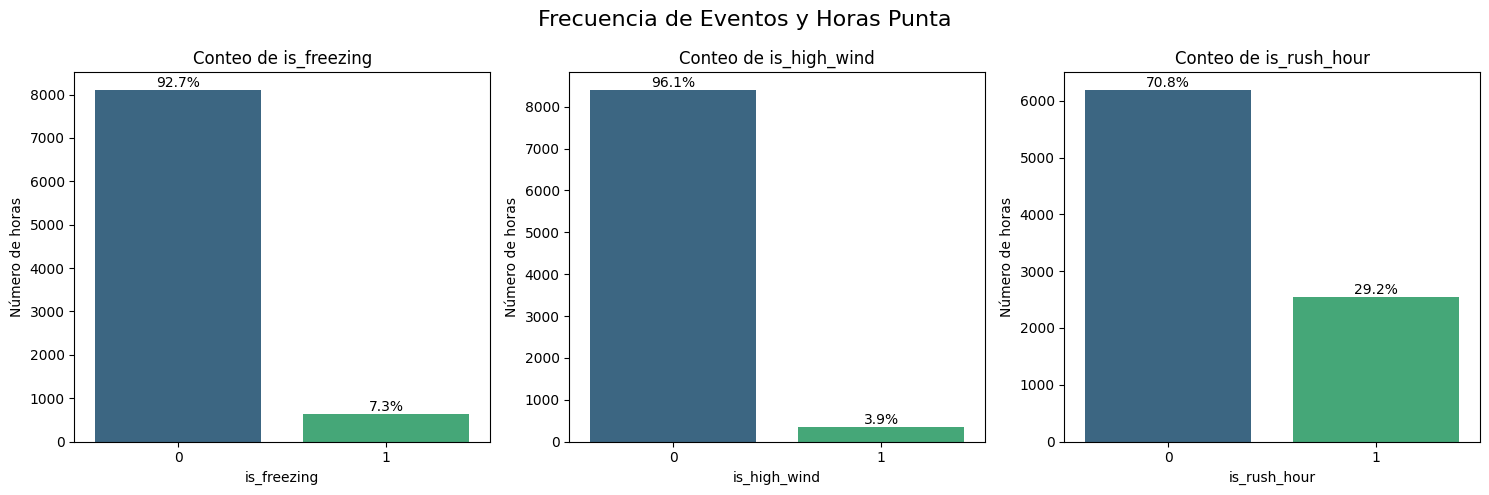

In [11]:
vars_binarias = ['is_freezing', 'is_high_wind', 'is_rush_hour']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Frecuencia de Eventos y Horas Punta', fontsize=16)

for i, var in enumerate(vars_binarias):
    sns.countplot(x=var, data=df, ax=axes[i], palette='viridis', hue=var, legend=False)
    
    axes[i].set_title(f'Conteo de {var}')
    axes[i].set_ylabel('Número de horas')
    
    total = len(df[var])
    for p in axes[i].patches:
        porcentaje = f'{100 * p.get_height() / total:.1f}%'
        axes[i].annotate(porcentaje, (p.get_x() + p.get_width() / 2., p.get_height()), 
                         ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## Análisis bivariante (Relaciones entre variables predictoras)

### Matriz de correlación (variables numéricas: continuas y binarias)

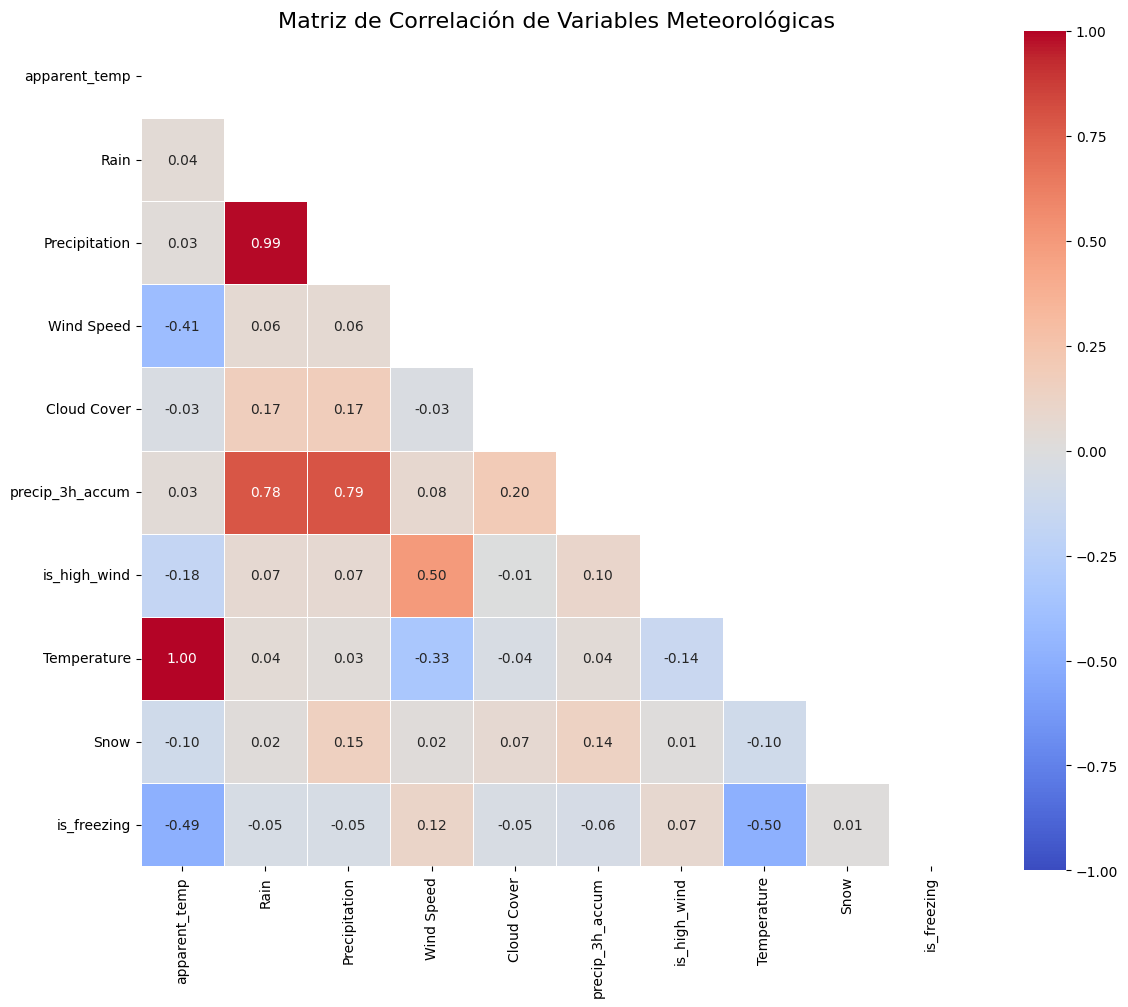

In [12]:
vars_numericas = [
    'apparent_temp', 'Rain', 'Precipitation', 
    'Wind Speed',  'Cloud Cover', 'precip_3h_accum',
    'is_high_wind', 'Temperature', 'Snow','is_freezing'

] 

matriz_corr = df[vars_numericas].corr()

mask = np.triu(np.ones_like(matriz_corr, dtype=bool))

plt.figure(figsize=(12, 10))
plt.title('Matriz de Correlación de Variables Meteorológicas', fontsize=16)

sns.heatmap(matriz_corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, linewidths=.5, 
            annot_kws={"size": 10})

plt.tight_layout()
plt.show()

### Análisis de colinealidad: pares con correlación |r| > 0.85

In [13]:
corr_unstacked = matriz_corr.abs().unstack()

# Filtramos las que son mayores a 0.85 pero menores a 1.0 (para que no salga Temperatura vs Temperatura)
alta_corr = corr_unstacked[(corr_unstacked > 0.85) & (corr_unstacked < 1.0)]

if alta_corr.empty:
    print("No se encontraron variables altamente correlacionadas.")
else:
    display(alta_corr.drop_duplicates().to_frame(name='Correlación'))

,,Correlación
apparent_temp,Temperature,0.995768
Rain,Precipitation,0.991607


## Relación con la variable a predecir

### Cargamos los dataset de trenes

In [15]:
print("--- 1. Identificando los días clave ---")
# Extraemos una lista de las fechas únicas donde hubo clima extremo
fechas_extremas = df_extremos['Date'].dt.strftime('%Y-%m-%d').unique()

print(f"Se han detectado {len(fechas_extremas)} días con clima extremo en todo el año.")
print(f"Fechas a descargar: {fechas_extremas[:5]}... (mostrando las 5 primeras)")

print("\n--- 2. Descargando SOLO los trenes de esos días ---")
lista_trenes_extremos = []

for date in fechas_extremas:
    ruta_trenes = f"grupo5/cleaned/gtfs_clean_scheduled/date={date}/gtfs_scheduled_{date}.parquet"
    
    try:
        # Descargamos el archivo de trenes SÓLO para este día conflictivo
        df_dia_tren = download_df_parquet(access_key, secret_key, ruta_trenes)
        
        if df_dia_tren is not None and not df_dia_tren.empty:
            
            # Ya que tenemos el día entero, vamos a quedarnos solo con las horas exactas que fueron extremas ese día
            horas_malas = df_extremos[df_extremos['Date'].dt.strftime('%Y-%m-%d') == date]['hour'].unique()
            
            # Calculamos la hora en el df de trenes y filtramos
            df_dia_tren['hour'] = (df_dia_tren['actual_seconds'] // 3600).fillna(-1).astype(int)
            df_dia_tren = df_dia_tren[df_dia_tren['hour'].isin(horas_malas)]
            
            # Añadimos a la lista
            lista_trenes_extremos.append(df_dia_tren)
            print(f"✓ Día {date} descargado y filtrado por horas extremas.")
            
    except Exception as e:
        # Si ese día no hay datos de trenes, lo saltamos
        print(f"✗ Error o sin datos en trenes para {date}")
        pass

print("\n--- 3. Unificando el Dataset Final ---")
if len(lista_trenes_extremos) > 0:
    df_trenes_extremo = pd.concat(lista_trenes_extremos, ignore_index=True)
    
    # Cruzamos (Merge) con df_extremo para añadirle las columnas de Lluvia, Temperatura, etc.
    df_trenes_extremo['Date'] = pd.to_datetime(df_trenes_extremo['service_date'], utc=True)
    df_merged_extremo = pd.merge(df_trenes_extremo, df_extremos, on=['Date', 'hour'], how='inner')
    
    print(f"\n¡Éxito total! Tienes tu df_master_extremo con {len(df_merged_extremo)} filas, sin haber saturado la RAM.")
else:
    print("\nNo se pudo descargar ningún tren para esas fechas.")

--- 1. Identificando los días clave ---
Se han detectado 161 días con clima extremo en todo el año.
Fechas a descargar: ['2025-01-01' '2025-01-02' '2025-01-03' '2025-01-04' '2025-01-05']... (mostrando las 5 primeras)

--- 2. Descargando SOLO los trenes de esos días ---
✓ Día 2025-01-01 descargado y filtrado por horas extremas.
✓ Día 2025-01-02 descargado y filtrado por horas extremas.
✓ Día 2025-01-03 descargado y filtrado por horas extremas.
✓ Día 2025-01-04 descargado y filtrado por horas extremas.
✓ Día 2025-01-05 descargado y filtrado por horas extremas.
✓ Día 2025-01-06 descargado y filtrado por horas extremas.
✓ Día 2025-01-07 descargado y filtrado por horas extremas.
✓ Día 2025-01-08 descargado y filtrado por horas extremas.
✓ Día 2025-01-09 descargado y filtrado por horas extremas.
✓ Día 2025-01-10 descargado y filtrado por horas extremas.
✓ Día 2025-01-11 descargado y filtrado por horas extremas.
✓ Día 2025-01-12 descargado y filtrado por horas extremas.
✓ Día 2025-01-13 desca

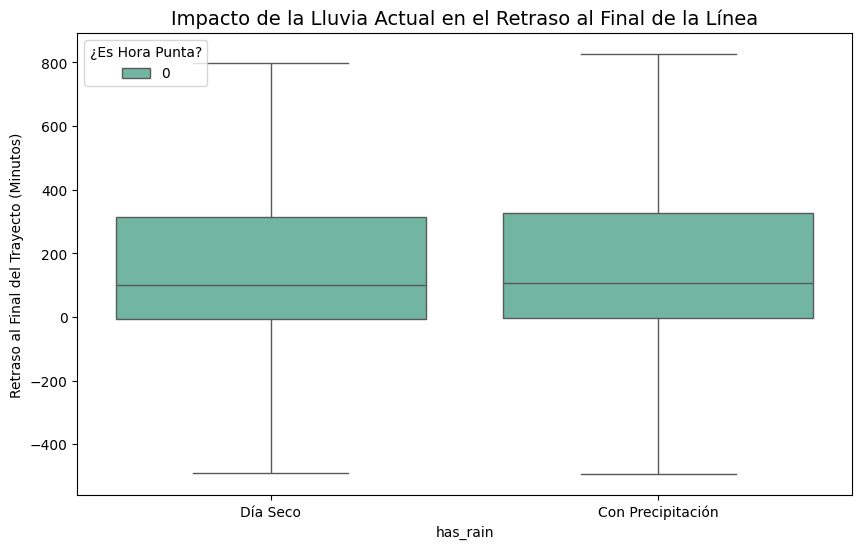

In [17]:
df_plot = df_merged_extremo.dropna(subset=['target_delay_end']).copy()
df_plot['has_rain'] = df_plot['Precipitation'] > 0

plt.figure(figsize=(10, 6))
# Usamos un boxplot sin outliers extremos (showfliers=False) para ver la mediana claramente
sns.boxplot(
    data=df_plot, 
    x='has_rain', 
    y='target_delay_end', 
    hue='is_peak', 
    palette='Set2', 
    showfliers=False
)

plt.title('Impacto de la Lluvia Actual en el Retraso al Final de la Línea', fontsize=14)
plt.ylabel('Retraso al Final del Trayecto (Minutos)')
plt.xticks([0, 1], ['Día Seco', 'Con Precipitación'])
plt.legend(title='¿Es Hora Punta?', loc='upper left')
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_22132\3146474268.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


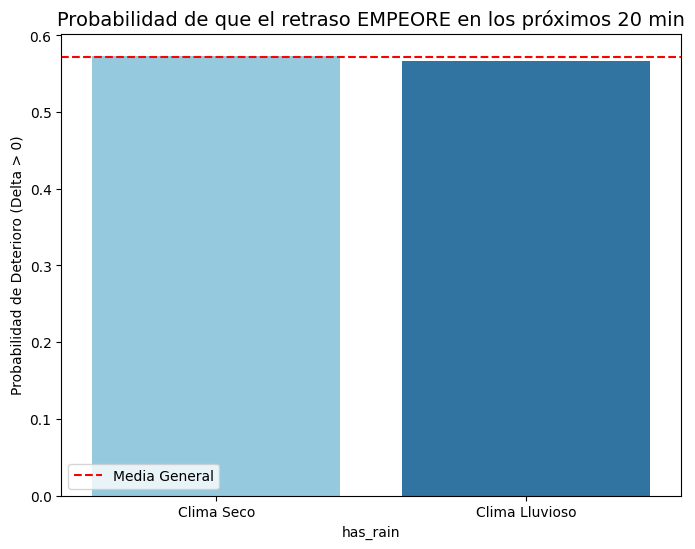

In [18]:
df_plot_delta = df_merged_extremo.dropna(subset=['delta_delay_20m']).copy()
df_plot_delta['has_rain'] = df_plot_delta['Precipitation'] > 0

# Calculamos la probabilidad de que el retraso EMPEORE en los próximos 20 min (delta > 0)
df_plot_delta['empeora_20m'] = (df_plot_delta['delta_delay_20m'] > 0).astype(int)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=df_plot_delta, 
    x='has_rain', 
    y='empeora_20m',
    palette=['#87CEEB', '#1f77b4'],
    errorbar=None
)

plt.title('Probabilidad de que el retraso EMPEORE en los próximos 20 min', fontsize=14)
plt.ylabel('Probabilidad de Deterioro (Delta > 0)')
plt.xticks([0, 1], ['Clima Seco', 'Clima Lluvioso'])
# Añadimos una línea horizontal con la media general para comparar
plt.axhline(df_plot_delta['empeora_20m'].mean(), color='red', linestyle='--', label='Media General')
plt.legend()
plt.show()

### Comparación 1: Retraso (delay_minutes) vs Lluvia (precipitation)

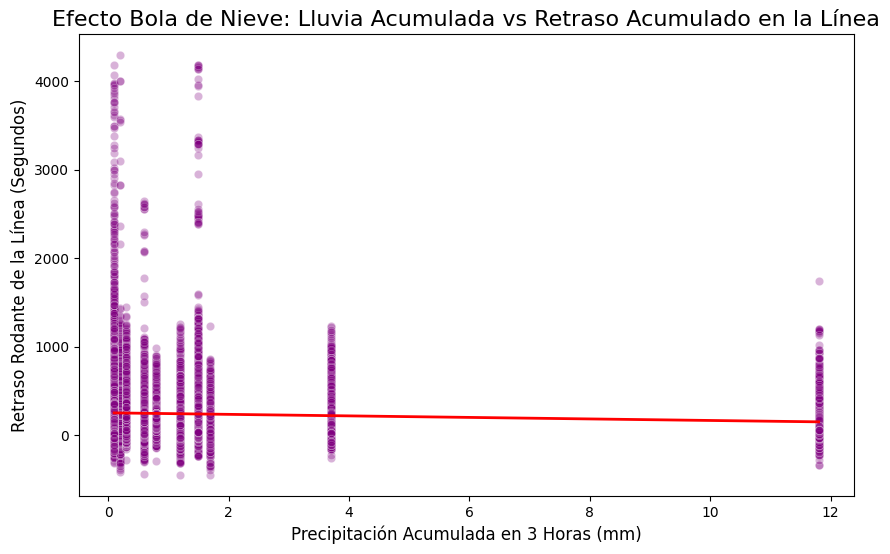

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_merged_extremo[df_merged_extremo['precip_3h_accum'] > 0], 
    x='precip_3h_accum', 
    y='route_rolling_delay', 
    alpha=0.3, 
    color='purple'
)

sns.regplot(
    data=df_merged_extremo[df_merged_extremo['precip_3h_accum'] > 0], 
    x='precip_3h_accum', 
    y='route_rolling_delay', 
    scatter=False, 
    color='red',
    line_kws={'linewidth': 2}
)

plt.title('Efecto Bola de Nieve: Lluvia Acumulada vs Retraso Acumulado en la Línea', fontsize=16)
plt.xlabel('Precipitación Acumulada en 3 Horas (mm)', fontsize=12)
plt.ylabel('Retraso Rodante de la Línea (Segundos)', fontsize=12)
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_22132\3276729770.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


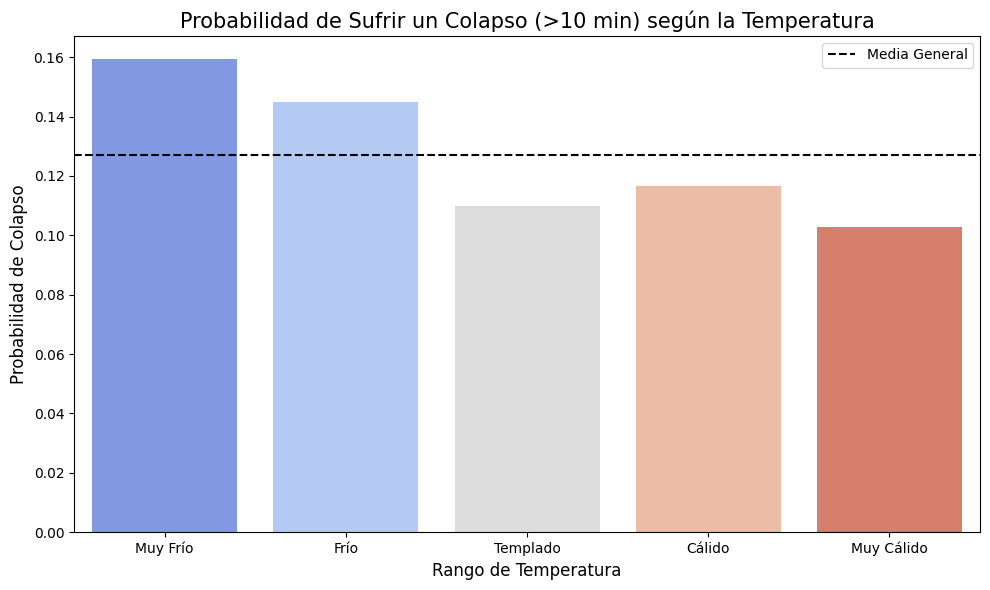

In [20]:
# 1. Definimos qué es un colapso (ej: más de 10 min de retraso)
df_merged_extremo['retraso_critico'] = (df_merged_extremo['delay_minutes'] > 10).astype(int)

# 2. Dividimos la Temperatura en 5 grupos iguales (del más frío al más cálido)
df_merged_extremo['temp_bins'] = pd.qcut(
    df_merged_extremo['Temperature'], 
    q=5, 
    labels=['Muy Frío', 'Frío', 'Templado', 'Cálido', 'Muy Cálido']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_merged_extremo, 
    x='temp_bins', 
    y='retraso_critico', 
    palette='coolwarm', 
    errorbar=None
)

# Añadimos la media general como referencia
plt.axhline(df_merged_extremo['retraso_critico'].mean(), color='black', linestyle='--', label='Media General')

plt.title('Probabilidad de Sufrir un Colapso (>10 min) según la Temperatura', fontsize=15)
plt.ylabel('Probabilidad de Colapso', fontsize=12)
plt.xlabel('Rango de Temperatura', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

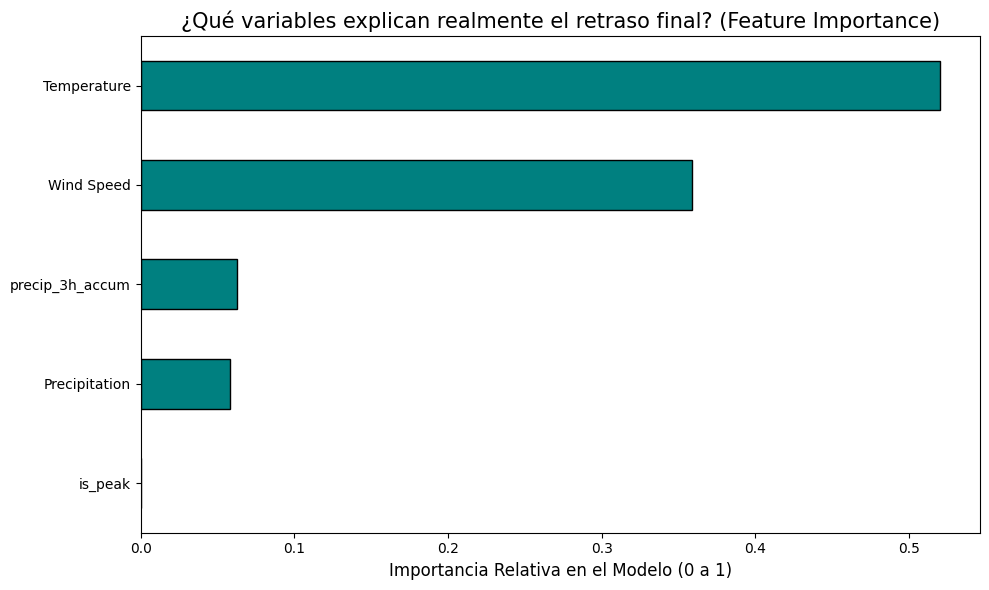

In [23]:
# 1. Elegimos las variables que queremos poner a competir
features = ['Temperature', 'Precipitation', 'Wind Speed', 'precip_3h_accum', 'is_peak']

target = 'target_delay_end'

# 2. Limpiamos nulos y sacamos una muestra de 50.000 filas para que se ejecute en 2 segundos
df_rf = df_merged_extremo.dropna(subset=features + [target]).sample(n=min(50000, len(df_merged_extremo)), random_state=42)

# 3. Entrenamos un bosque aleatorio pequeño
rf = RandomForestRegressor(n_estimators=50, max_depth=6, random_state=42, n_jobs=-1)
rf.fit(df_rf[features], df_rf[target])

# 4. Extraemos y graficamos la importancia de las variables
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importancias.plot(kind='barh', color='teal', edgecolor='black')
plt.title('¿Qué variables explican realmente el retraso final? (Feature Importance)', fontsize=15)
plt.xlabel('Importancia Relativa en el Modelo (0 a 1)', fontsize=12)
plt.tight_layout()
plt.show()

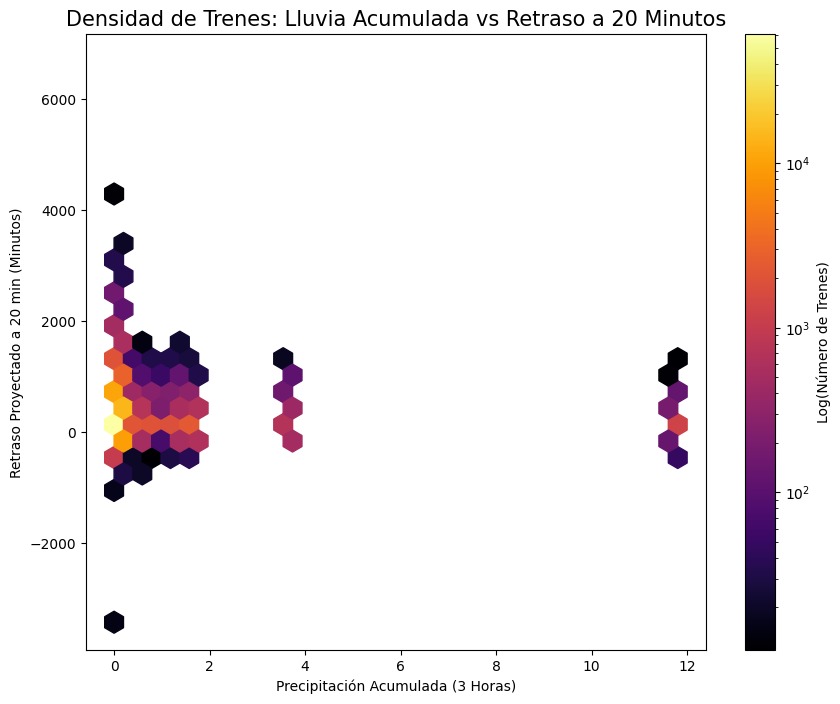

In [25]:
plt.figure(figsize=(10, 8))

# Usamos hexbin para ver densidades en datasets masivos
# Cambia 'precip_3h_accum' por 'Wind Speed' si quieres probar el viento
hb = plt.hexbin(
    x=df_merged_extremo['precip_3h_accum'], 
    y=df_merged_extremo['target_delay_20m'], 
    gridsize=30, 
    cmap='inferno', 
    mincnt=10, # Solo pinta hexágonos si hay más de 10 trenes ahí
    bins='log' # Escala logarítmica porque la mayoría de trenes están en 0 retraso
)

plt.colorbar(hb, label='Log(Número de Trenes)')
plt.title('Densidad de Trenes: Lluvia Acumulada vs Retraso a 20 Minutos', fontsize=15)
plt.xlabel('Precipitación Acumulada (3 Horas)')
plt.ylabel('Retraso Proyectado a 20 min (Minutos)')
plt.show()

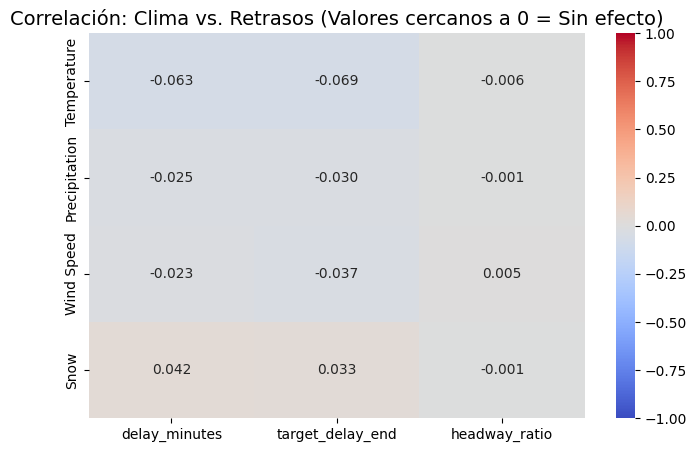

In [26]:
# Seleccionamos las variables del clima y las de retraso
cols_clima = ['Temperature', 'Precipitation', 'Wind Speed', 'Snow']
cols_trenes = ['delay_minutes', 'target_delay_end', 'headway_ratio']

# Calculamos la correlación solo entre estos dos grupos
corr_matrix = df_merged_extremo[cols_clima + cols_trenes].corr().loc[cols_clima, cols_trenes]

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    center=0, 
    vmin=-1, vmax=1,
    fmt=".3f"
)
plt.title('Correlación: Clima vs. Retrasos (Valores cercanos a 0 = Sin efecto)', fontsize=14)
plt.show()

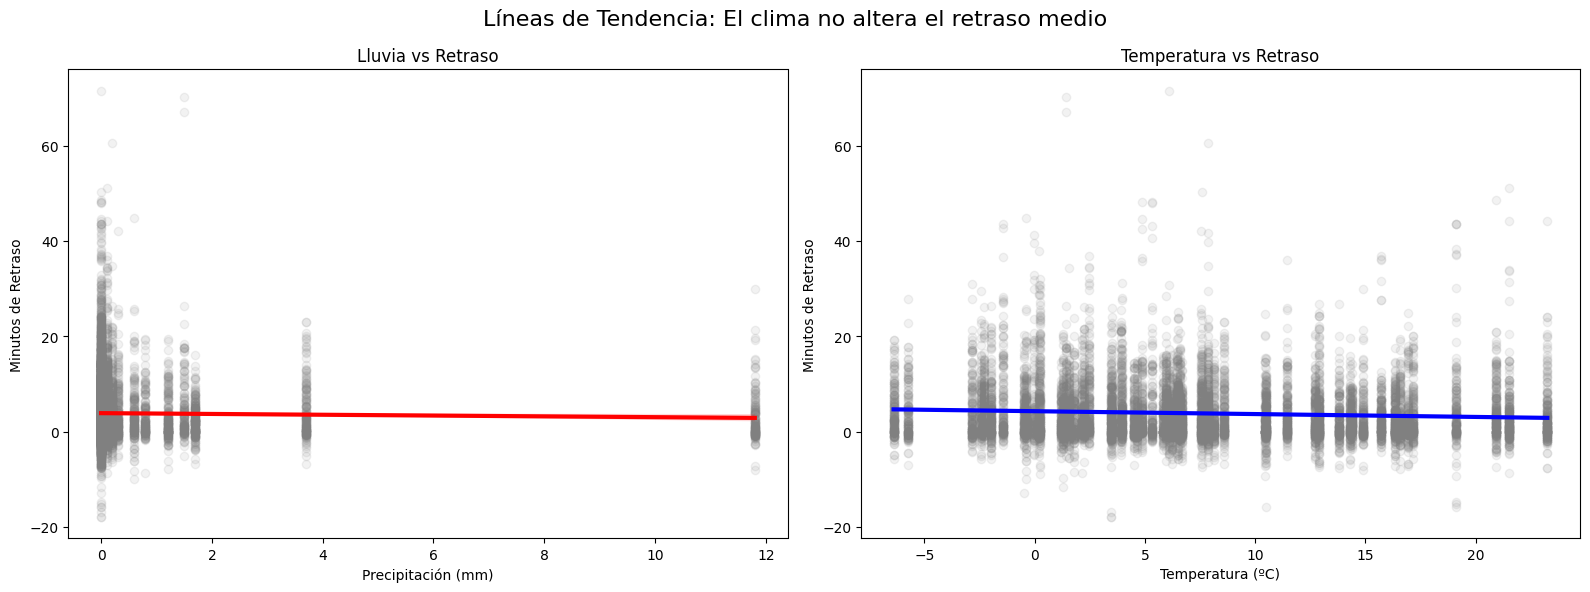

In [27]:
# Hacemos una muestra de 10,000 puntos para que el gráfico cargue rápido
df_sample = df_merged_extremo.dropna(subset=['Precipitation', 'delay_minutes']).sample(n=min(10000, len(df_merged_extremo)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Líneas de Tendencia: El clima no altera el retraso medio', fontsize=16)

# Gráfico 1: Lluvia vs Retraso
sns.regplot(
    data=df_sample, 
    x='Precipitation', 
    y='delay_minutes', 
    ax=axes[0], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'red', 'linewidth': 3}
)
axes[0].set_title('Lluvia vs Retraso')
axes[0].set_xlabel('Precipitación (mm)')
axes[0].set_ylabel('Minutos de Retraso')

# Gráfico 2: Temperatura vs Retraso
sns.regplot(
    data=df_sample, 
    x='Temperature', 
    y='delay_minutes', 
    ax=axes[1], 
    scatter_kws={'alpha': 0.1, 'color': 'gray'}, 
    line_kws={'color': 'blue', 'linewidth': 3}
)
axes[1].set_title('Temperatura vs Retraso')
axes[1].set_xlabel('Temperatura (ºC)')
axes[1].set_ylabel('Minutos de Retraso')

plt.tight_layout()
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_22132\1698242205.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


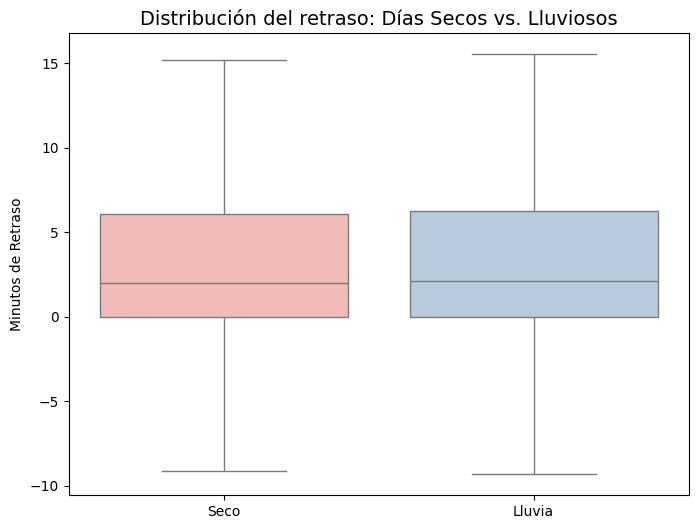

In [28]:
# Creamos una variable binaria simple
df_merged_extremo['condicion_clima'] = df_merged_extremo['Precipitation'].apply(lambda x: 'Lluvia' if x > 0 else 'Seco')

plt.figure(figsize=(8, 6))
# showfliers=False quita los puntos extremos para ver claramente dónde está el grueso de los trenes
sns.boxplot(
    data=df_merged_extremo, 
    x='condicion_clima', 
    y='delay_minutes', 
    palette='Pastel1',
    showfliers=False 
)

plt.title('Distribución del retraso: Días Secos vs. Lluviosos', fontsize=14)
plt.ylabel('Minutos de Retraso')
plt.xlabel('')
plt.show()

In [29]:

df_merged_extremo['Wind Speed'].quantile(0.95)

np.float64(58.46121597290039)

## 1) Creación de banderas de clima extremo (Umbrales)

In [30]:
# Banderas de clima extremo (0/1)
df_merged_extremo['is_flooding_risk'] = (df_merged_extremo['precip_3h_accum'] > 1).astype(int)
df_merged_extremo['is_extreme_heat'] = (df_merged_extremo['Temperature'] > 7.0).astype(int)
df_merged_extremo['is_blizzard'] = ((df_merged_extremo['Snow'] > 0) & (df_merged_extremo['Wind Speed'] > 25)).astype(int)

# Media de delay_minutes agrupada por riesgo de inundación
delay_por_flooding = (
    df_merged_extremo.groupby('is_blizzard', dropna=False)['delay_minutes']
    .mean()
    .rename('avg_delay_minutes')
)
display(delay_por_flooding.to_frame())

,avg_delay_minutes
is_blizzard,
0,3.842125
1,4.398456


## 2) El efecto "pasajero mojado" (Interacción Clima x Hora Punta)

C:\Users\julia\AppData\Local\Temp\ipykernel_22132\149213307.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


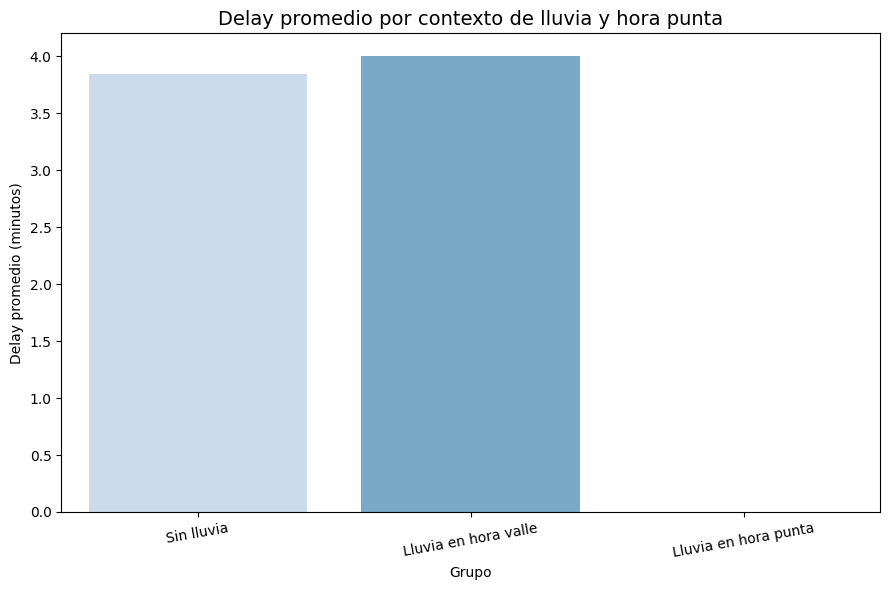

In [31]:
# Interacción lluvia x hora punta
df_merged_extremo['rain_x_peak'] = ((df_merged_extremo['Precipitation'] > 0) & (df_merged_extremo['is_peak'] == 1)).astype(int)

# Definimos 3 grupos mutuamente excluyentes
df_merged_extremo['grupo_lluvia_peak'] = 'Sin lluvia'
df_merged_extremo.loc[(df_merged_extremo['Precipitation'] > 0) & (df_merged_extremo['is_peak'] == 0), 'grupo_lluvia_peak'] = 'Lluvia en hora valle'
df_merged_extremo.loc[df_merged_extremo['rain_x_peak'] == 1, 'grupo_lluvia_peak'] = 'Lluvia en hora punta'

orden_grupos = ['Sin lluvia', 'Lluvia en hora valle', 'Lluvia en hora punta']

plt.figure(figsize=(9, 6))
sns.barplot(
    data=df_merged_extremo,
    x='grupo_lluvia_peak',
    y='delay_minutes',
    order=orden_grupos,
    estimator=np.mean,
    errorbar=None,
    palette='Blues'
 )
plt.title('Delay promedio por contexto de lluvia y hora punta', fontsize=14)
plt.xlabel('Grupo')
plt.ylabel('Delay promedio (minutos)')
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 3) Exterior vs subterráneo (Topología)

C:\Users\julia\AppData\Local\Temp\ipykernel_22132\463507824.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


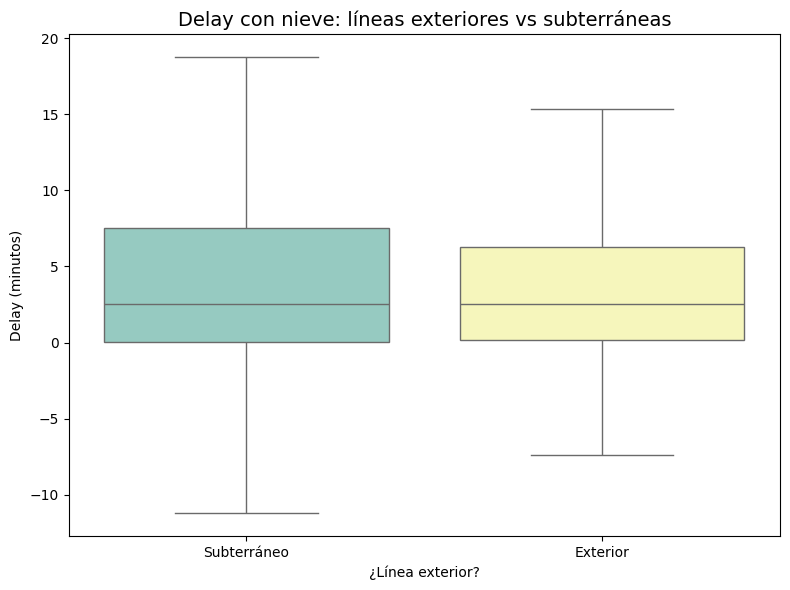

In [32]:
lineas_exteriores = ['7', 'N', 'Q', 'J', 'Z', 'B', 'D']

# True si la línea tiene mucho tramo exterior
df_merged_extremo['is_exterior'] = df_merged_extremo['route_id'].astype(str).isin(lineas_exteriores)

# Filtramos solo observaciones con nieve
df_snow = df_merged_extremo[df_merged_extremo['Snow'] > 0].copy()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_snow,
    x='is_exterior',
    y='delay_minutes',
    showfliers=False,
    palette='Set3'
 )
plt.title('Delay con nieve: líneas exteriores vs subterráneas', fontsize=14)
plt.xlabel('¿Línea exterior?')
plt.ylabel('Delay (minutos)')
plt.xticks([0, 1], ['Subterráneo', 'Exterior'])
plt.tight_layout()
plt.show()

## 4) Predicción de la recuperación (Delta)

,avg_delta_delay_30m
condicion_clima,
Seco,-95.237234
Lluvia,-135.795830


C:\Users\julia\AppData\Local\Temp\ipykernel_22132\2919033561.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


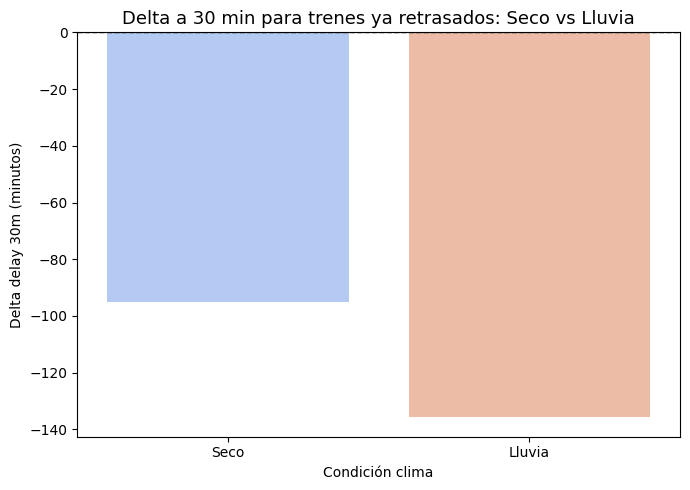

In [33]:
# Creamos/normalizamos condición climática: Seco vs Lluvia
df_merged_extremo


df_merged_extremo['condicion_clima'] = np.where(df_merged_extremo['Precipitation'] > 0, 'Lluvia', 'Seco')

# Filtramos trenes que ya van tarde
df_tarde = df_merged_extremo[df_merged_extremo['delay_minutes'] > 2].copy()

# Media de delta_delay_30m por condición climática
delta_por_clima = (
    df_tarde.groupby('condicion_clima', dropna=False)['delta_delay_30m']
    .mean()
    .reindex(['Seco', 'Lluvia'])
    .rename('avg_delta_delay_30m')
)
display(delta_por_clima.to_frame())

plt.figure(figsize=(7, 5))
sns.barplot(
    x=delta_por_clima.index,
    y=delta_por_clima.values,
    palette='coolwarm',
    errorbar=None
 )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Delta a 30 min para trenes ya retrasados: Seco vs Lluvia', fontsize=13)
plt.xlabel('Condición clima')
plt.ylabel('Delta delay 30m (minutos)')
plt.tight_layout()
plt.show()